- CNN의 종류(https://zzzl-coding.tistory.com/29)
---
### 실습 내용
-  모델의 효율성 향상을 위한 네트워크의 확장
- fashion mnist로
  - 1) Conv + Dense
  - 2) Conv + Pooling + Dense
  - 3) **유명모델의 네트워크**
- 사용하여 모델 작성 후 성능비교하기

In [ ]:
import tensorflow as tf

fashin_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashin_mnist.load_data()
print(x_train.shape, y_train.shape) # (60000, 28, 28) (60000,)
print(x_test.shape, y_test.shape)   # (10000, 28, 28) (10000,)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


(60000, 28, 28) (10000, 28, 28)


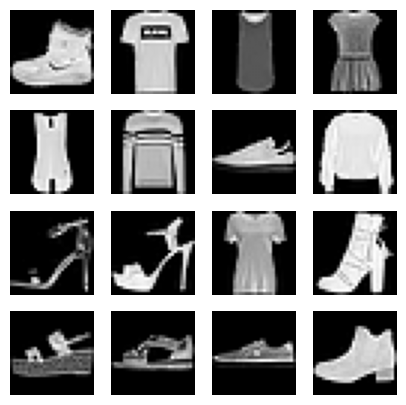

[9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9]


In [ ]:
x_train = x_train / 255.0 # 정규화
x_test = x_test / 255.0

# reshape 이전
print(x_train.shape, x_test.shape) # (60000, 28, 28) (10000, 28, 28)

# reshape -> 채널을 줘야함 - 흑백(-1:행의 갯수는 잘모르겠어, 28, 28, 1:채널은 흑백이야) -> 4차원으로 늘어남(CNN을 사용하기 위해)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 데이터 확인(시각화)
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
for c in range(16):
  plt.subplot(4, 4, c+1)
  plt.imshow(x_train[c].reshape(28, 28), cmap='gray')
  plt.axis('off')
plt.show()
print(y_train[:16])

In [ ]:
# 1) Conv + Dense
model1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), strides=1),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), strides=1),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=10, activation='softmax')
])
print(model1.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,982,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,234 (7.66 MB)

 Trainable params: 2,008,234 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history1 = model1.fit(x_train, y_train, batch_size=32, epochs=15, validation_split=0.25, verbose=2)
loss , acc = model1.evaluate(x_test, y_test, verbose=0)
print(f'Model1 => loss :{loss:.4f}, acc :{acc:.4f}')

Epoch 1/15
1407/1407 - 18s - 13ms/step - accuracy: 0.7992 - loss: 0.5766 - val_accuracy: 0.8417 - val_loss: 0.4299
Epoch 2/15
1407/1407 - 7s - 5ms/step - accuracy: 0.8330 - loss: 0.4720 - val_accuracy: 0.8575 - val_loss: 0.4005
Epoch 3/15
1407/1407 - 8s - 6ms/step - accuracy: 0.8456 - loss: 0.4304 - val_accuracy: 0.8612 - val_loss: 0.3921
Epoch 4/15
1407/1407 - 8s - 6ms/step - accuracy: 0.8538 - loss: 0.4048 - val_accuracy: 0.8609 - val_loss: 0.3879
Epoch 5/15
1407/1407 - 8s - 6ms/step - accuracy: 0.8620 - loss: 0.3826 - val_accuracy: 0.8680 - val_loss: 0.3791
Epoch 6/15
1407/1407 - 6s - 5ms/step - accuracy: 0.8660 - loss: 0.3674 - val_accuracy: 0.8626 - val_loss: 0.3859
Epoch 7/15
1407/1407 - 7s - 5ms/step - accuracy: 0.8707 - loss: 0.3547 - val_accuracy: 0.8578 - val_loss: 0.3844
Epoch 8/15
1407/1407 - 8s - 5ms/step - accuracy: 0.8724 - loss: 0.3457 - val_accuracy: 0.8683 - val_loss: 0.3784
Epoch 9/15
1407/1407 - 7s - 5ms/step - accuracy: 0.8764 - loss: 0.3357 - val_accuracy: 0.8668 

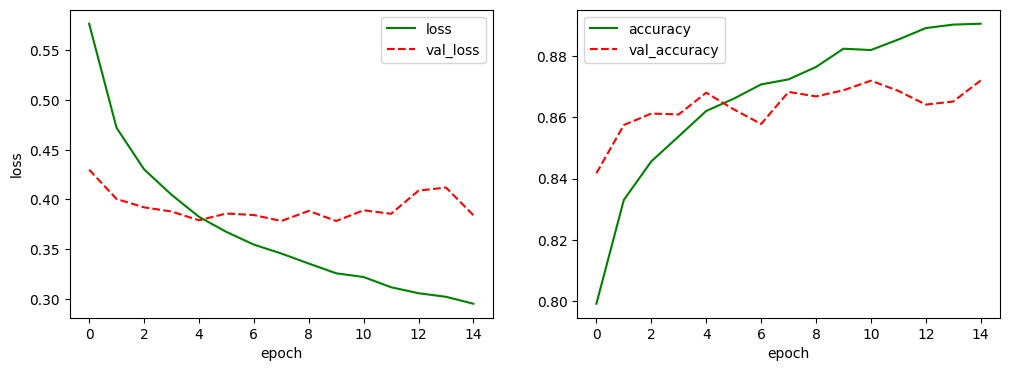

In [ ]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], 'g-', label='loss')
plt.plot(history1.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history1.history['accuracy'], 'g-', label='accuracy')
plt.plot(history1.history['val_accuracy'], 'r--', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [ ]:
# 2) Conv + Pooling + Dense - paramater수가 줄었다!
model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), strides=1),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), strides=1),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=10, activation='softmax')
])
print(model2.summary())

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history2 = model2.fit(x_train, y_train, batch_size=32, epochs=15, validation_split=0.25, verbose=2)
loss , acc = model2.evaluate(x_test, y_test, verbose=0)
print(f'Model2 => loss :{loss:.4f}, acc :{acc:.4f}')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,866 (116.66 KB)

 Trainable params: 29,866 (116.66 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
1407/1407 - 16s - 11ms/step - accuracy: 0.7182 - loss: 0.7882 - val_accuracy: 0.8008 - val_loss: 0.5324
Epoch 2/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8110 - loss: 0.5371 - val_accuracy: 0.8251 - val_loss: 0.4762
Epoch 3/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8338 - loss: 0.4662 - val_accuracy: 0.8367 - val_loss: 0.4457
Epoch 4/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8485 - loss: 0.4292 - val_accuracy: 0.8527 - val_loss: 0.4037
Epoch 5/15
1407/1407 - 7s - 5ms/step - accuracy: 0.8564 - loss: 0.4014 - val_accuracy: 0.8533 - val_loss: 0.3896
Epoch 6/15
1407/1407 - 5s - 4ms/step - accuracy: 0.8665 - loss: 0.3764 - val_accuracy: 0.8618 - val_loss: 0.3675
Epoch 7/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8729 - loss: 0.3557 - val_accuracy: 0.8685 - val_loss: 0.3601
Epoch 8/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8764 - loss: 0.3428 - val_accuracy: 0.8685 - val_loss: 0.3612
Epoch 9/15
1407/1407 - 5s - 4ms/step - accuracy: 0.8823 - loss: 0.3280 - val_accuracy: 0.

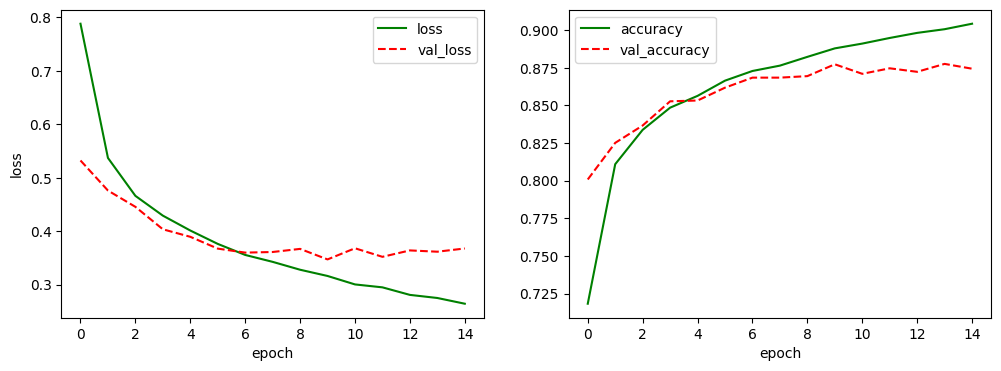

In [ ]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'], 'g-', label='loss')
plt.plot(history2.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history2.history['accuracy'], 'g-', label='accuracy')
plt.plot(history2.history['val_accuracy'], 'r--', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [ ]:
#  3) **유명모델의 네트워크(효율성이 좋은, 성능이 우수한)**를 이용해 일부구조(신경망)를 사용
# vggnet 사용(https://cafe.daum.net/flowlife/S2Ul/31)
# VGG Net흉내만 내봄
model3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(input_shape=(28,28,1), kernel_size=(3,3), filters=32, padding='same', activation='relu'),
    tf.keras.layers.Conv2D(kernel_size=(3,3), filters=64, padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Conv2D(kernel_size=(3,3), filters=128, padding='same', activation='relu'),
    tf.keras.layers.Conv2D(kernel_size=(3,3), filters=256, padding='valid', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(units=10, activation='softmax')
])
print(model3.summary())
model3.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history3 = model3.fit(x_train, y_train, batch_size=32, epochs=15, validation_split=0.25, verbose=2)
loss , acc = model3.evaluate(x_test, y_test, verbose=0)
print(f'Model3 => loss :{loss:.4f}, acc :{acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,240,842 (19.99 MB)

 Trainable params: 5,240,842 (19.99 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
1407/1407 - 27s - 20ms/step - accuracy: 0.7864 - loss: 0.5844 - val_accuracy: 0.8728 - val_loss: 0.3324
Epoch 2/15
1407/1407 - 11s - 8ms/step - accuracy: 0.8648 - loss: 0.3778 - val_accuracy: 0.8855 - val_loss: 0.2985
Epoch 3/15
1407/1407 - 11s - 8ms/step - accuracy: 0.8821 - loss: 0.3271 - val_accuracy: 0.9096 - val_loss: 0.2565
Epoch 4/15
1407/1407 - 12s - 9ms/step - accuracy: 0.8904 - loss: 0.3018 - val_accuracy: 0.9137 - val_loss: 0.2318
Epoch 5/15
1407/1407 - 11s - 8ms/step - accuracy: 0.8940 - loss: 0.2950 - val_accuracy: 0.9198 - val_loss: 0.2292
Epoch 6/15
1407/1407 - 12s - 8ms/step - accuracy: 0.9005 - loss: 0.2799 - val_accuracy: 0.9106 - val_loss: 0.2384
Epoch 7/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9036 - loss: 0.2716 - val_accuracy: 0.9189 - val_loss: 0.2219
Epoch 8/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9074 - loss: 0.2646 - val_accuracy: 0.9203 - val_loss: 0.2194
Epoch 9/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9078 - loss: 0.2582 - val_accu

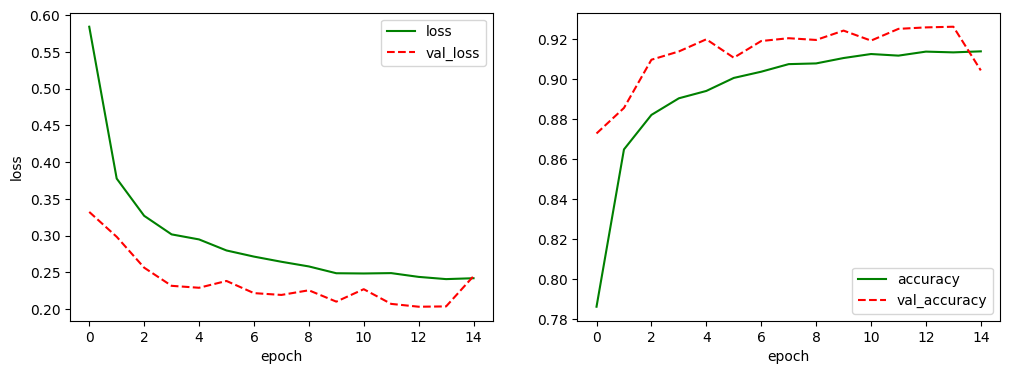

In [ ]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history3.history['loss'], 'g-', label='loss')
plt.plot(history3.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history3.history['accuracy'], 'g-', label='accuracy')
plt.plot(history3.history['val_accuracy'], 'r--', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()